In [ ]:
# 1. Install Unsloth & dependencies
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.28" "trl<0.9.0" "peft" "accelerate" "bitsandbytes"
!pip install --upgrade git+https://github.com/huggingface/transformers.git accelerate peft torchao

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-ijrjbjav/unsloth_34a90a7503134a3fa25a5a7e1b88dad1
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-ijrjbjav/unsloth_34a90a7503134a3fa25a5a7e1b88dad1
  Resolved https://github.com/unslothai/unsloth.git to commit 0003f889e6b8dd0a8da21cb382f175dab17985ac
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 158.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.4/924.4 kB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 22.3 MB/s eta 0:00:0

In [ ]:
from unsloth import FastLanguageModel
import torch
import os
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import drive
drive.mount('/content/drive')

# 1. Definisi Path
ROOT_PATH = "/content/drive/MyDrive/SFT"
OUTPUT_PATH = "/content/drive/MyDrive/SFT/Kebutuhan Tim 1/Ujicoba SFT Notebook"
os.makedirs(OUTPUT_PATH, exist_ok=True)
# 2. Setup Model & Tokenizer
MODEL_NAME = "aitf-komdigi/KomdigiITS-8B-DFK-CPT"
LEARNING_RATE = 2e-4
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEP = 16
EPOCH = 1
MAX_SEQ_LENGTH = 2048


print("Setup selesai. Model siap untuk fine-tuning!")

Mounted at /content/drive
Setup selesai. Model siap untuk fine-tuning!


In [ ]:
# =====================================================================
# CELL BARU: LOGIN CREDENTIALS & CREDENTIALS SETUP
# =====================================================================
import os
import wandb
from huggingface_hub import login

# 1. Isi token kamu di sini
HF_TOKEN = "xxx"
WANDB_KEY = "xxx"

# 2. Eksekusi Login Sistem
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN, add_to_git_credential=True)

if WANDB_KEY:
    os.environ["WANDB_API_KEY"] = WANDB_KEY
    wandb.login(key=WANDB_KEY, relogin=True)
    REPORT_TO_VAL = "wandb"
    print("✅ W&B dan Hugging Face Hub berhasil tersambung!")
else:
    REPORT_TO_VAL = "none"
    print("⚠️ API Key W&B kosong, logging W&B dinonaktifkan.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: halizaapalwan (halizaapalwan-sepuluh-nopember-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B dan Hugging Face Hub berhasil tersambung!


In [ ]:
# 3. Load Model & Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

# 4. Ambil model untuk PEFT (LoRA) agar training lebih efisien
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Faktor rank LoRA, bisa diganti 8, 16, 32, atau 64
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0, #
    bias = "none",    # Unsloth mengoptimalkan bias ke none
    use_gradient_checkpointing = "unsloth", # Menghemat VRAM secara maksimal
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 5. Menyuntikkan Chat Template Jinja (Tanpa THINK) ke Tokenizer
no_think_template = """{#- Begin of sequence token. -#}
{{- bos_token }}
{#- Handle system prompt jika ada. -#}
{%- if messages[0]['role'] == 'system' %}
    {{- '[SYSTEM_PROMPT]' + messages[0]['content'] + '[/SYSTEM_PROMPT]' }}
    {%- set loop_messages = messages[1:] %}
{%- else %}
    {%- set loop_messages = messages %}
{%- endif %}
{#- Handle iterasi untuk User dan Assistant -#}
{%- for message in loop_messages %}
    {%- if message['role'] == 'user' %}
        {{- '[INST]' + message['content'] + '[/INST]' }}
    {%- elif message['role'] == 'assistant' %}
        {{- message['content'] + eos_token }}
    {%- endif %}
{%- endfor %}"""

tokenizer.chat_template = no_think_template
tokenizer.pad_token = tokenizer.eos_token

==((====))==  Unsloth 2026.6.1: Fast Ministral3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/17.8G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/177k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

## DATA FORMATTING

In [ ]:
# =====================================================================
# CELL 2: DATA FORMATTING & DIRECT TOKENIZATION (PERBAIKAN VALUEERROR)
# =====================================================================
import os
from datasets import load_dataset

print("Memuat dataset DFK...")
dataset_path = os.path.join(ROOT_PATH, "datasetSFT_tlr.jsonl")
dataset = load_dataset("json", data_files=dataset_path, split="train")

# 1. Ekstrak tokenizer teks murni secara aman
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. SUNTIKKAN ULANG TEMPLATE JINJA LANGSUNG KE ACTUAL_TOKENIZER
# Ini memastikan template tidak hilang saat diekstrak dari processor
actual_tokenizer.chat_template = no_think_template

# 3. Fungsi untuk mengubah pesan menjadi Token IDs (Text-Only)
def tokenize_and_format_func(examples):
    convos = examples["messages"]

    # Render ke format text prompt Mistral tanpa THINK menggunakan actual_tokenizer
    templated_texts = [
        actual_tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
        for convo in convos
    ]

    # Tokenisasi langsung teks tersebut menjadi angka (IDs)
    tokenized = actual_tokenizer(
        templated_texts,
        truncation=False,            # Kita biarkan utuh agar bisa difilter di Cell 3
        add_special_tokens=False     # Karena template Jinja kita sudah membuat BOS/EOS sendiri
    )

    # Hitung panjang token untuk keperluan filtering cepat di Cell 3
    token_lengths = [len(ids) for ids in tokenized["input_ids"]]

    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "token_len": token_lengths,
        "raw_text": templated_texts  # Simpan teks sementara untuk kebutuhan visualisasi/ekstraksi label di Cell 3
    }

print("Memproses format prompt dan melakukan tokenisasi langsung...")
dataset_processed = dataset.map(tokenize_and_format_func, batched=True)

# Hapus kolom 'messages' asli agar hemat RAM Kaggle
dataset_processed = dataset_processed.remove_columns(["messages"])

print("\n✅ Proses Tokenisasi Selesai Tanpa Error!")
print(f"Kolom yang tersedia sekarang: {dataset_processed.column_names}")

Memuat dataset DFK...


Generating train split: 0 examples [00:00, ? examples/s]

Memproses format prompt dan melakukan tokenisasi langsung...


Map:   0%|          | 0/26342 [00:00<?, ? examples/s]


✅ Proses Tokenisasi Selesai Tanpa Error!
Kolom yang tersedia sekarang: ['input_ids', 'attention_mask', 'token_len', 'raw_text']


## DISTRIBUSI & FILTER DATA

Merender teks prompt menggunakan template Jinja...
Mengekstrak label kelas awal...
Menghitung statistik panjang token awal...

       STATISTIK PROSES FILTERING
Jumlah data SEBELUM filter : 26342
Jumlah data SETELAH filter: 25988
Data yang dibuang           : 354 baris
Max Token Setelah Filter    : 2048

--- Perbandingan Distribusi Label (Before vs After) ---
                  Before  After
Bukan DFK           5269   5125
Disinformasi        5269   5269
Fakta               5269   5156
Fitnah              5269   5172
Ujaran Kebencian    5266   5266


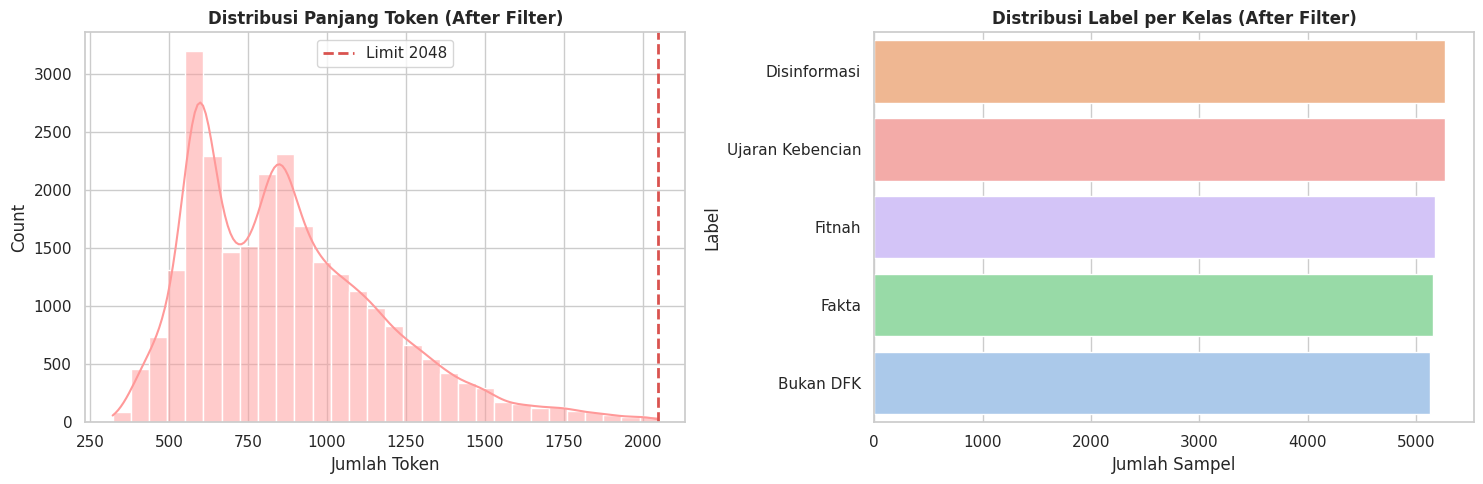

In [ ]:
# =====================================================================
# CELL 3: ANALISIS STATISTIK, FILTERING, & VISUALISASI DATASET
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Ekstrak tokenizer teks murni secara aman
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
actual_tokenizer.chat_template = no_think_template

# 2. Render teks lewat chat template untuk seluruh data awal
print("Merender teks prompt menggunakan template Jinja...")
all_templated_texts = [
    actual_tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
    for convo in dataset["messages"]
]

# Fungsi ekstraksi label (untuk membandingkan before & after)
def extract_label_clean(text):
    parts = text.split("[/INST]")
    if len(parts) < 2: return "Unknown"
    assistant_response = parts[1]
    match = re.search(r"Label:\s*\*\*(.*?)\*\*", assistant_response, re.IGNORECASE)
    if match:
        label = match.group(1).replace(".", "").strip()
        return "Unknown" if label.lower() == "namalabel" else label
    return "Unknown"

print("Mengekstrak label kelas awal...")
labels_all = [extract_label_clean(t) for t in all_templated_texts]

# 3. Hitung panjang token secara efisien sebelum filter
print("Menghitung statistik panjang token awal...")
token_lengths_all = [len(actual_tokenizer.encode(t, add_special_tokens=False)) for t in all_templated_texts]

# Buat DataFrame induk untuk mempermudah manipulasi data
df_raw = pd.DataFrame({
    "text": all_templated_texts,
    "label": labels_all,
    "token_len": token_lengths_all
})

# 4. Proses Filter data yang melebihi 2048 Token
df_filtered = df_raw[df_raw["token_len"] <= 2048].reset_index(drop=True)

print("\n" + "="*40)
print("       STATISTIK PROSES FILTERING")
print("="*40)
print(f"Jumlah data SEBELUM filter : {len(df_raw)}")
print(f"Jumlah data SETELAH filter: {len(df_filtered)}")
print(f"Data yang dibuang           : {len(df_raw) - len(df_filtered)} baris")
print(f"Max Token Setelah Filter    : {df_filtered['token_len'].max()}")

# 5. Tabel Perbandingan Distribusi Label (Before vs After)
df_labels_after = df_filtered[df_filtered["label"] != "Unknown"]
counts_before = pd.Series(labels_all).value_counts().drop("Unknown", errors='ignore')
counts_after = df_labels_after["label"].value_counts()
df_comparison = pd.DataFrame({"Before": counts_before, "After": counts_after}).fillna(0).astype(int)

print("\n--- Perbandingan Distribusi Label (Before vs After) ---")
print(df_comparison)

# 6. Visualisasi Grafik (Tema Pastel)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot distribusi token (After Filter)
sns.histplot(df_filtered["token_len"], kde=True, ax=axes[0], color='#ff9999', bins=30)
axes[0].set_title("Distribusi Panjang Token (After Filter)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Jumlah Token")
axes[0].axvline(2048, color='#d9534f', linestyle='--', linewidth=2, label='Limit 2048')
axes[0].legend()

# Plot distribusi label per kelas (After Filter)
sns.countplot(y=df_labels_after["label"], ax=axes[1], palette="pastel",
              order=df_labels_after["label"].value_counts().index,
              hue=df_labels_after["label"], legend=False)
axes[1].set_title("Distribusi Label per Kelas (After Filter)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Jumlah Sampel")
axes[1].set_ylabel("Label")

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# CELL 4: STRATIFIED SPLIT DATASET TEKS MENTAH (PERBAIKAN)
# =====================================================================
from sklearn.model_selection import train_test_split
from datasets import Dataset
import pandas as pd

# 1. Split data menjadi Train (80%) dan Sisanya (20% untuk Test + Validation)
# Kita gunakan kolom df_filtered["label"] untuk stratifikasi agar proporsi kelas DFK seimbang
train_df, temp_df = train_test_split(
    df_filtered, test_size=0.2, stratify=df_filtered["label"], random_state=3407
)

# 2. Split Sisanya (20%) menjadi Test (10%) dan Validation (10%)
test_df, val_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=3407
)

# 3. SANITY CHECK: Memastikan distribusi label seimbang di tiap subset teks
def check_balance(df, name):
    print(f"\n--- Distribusi Label di {name} (Total: {len(df)} baris) ---")
    print(df["label"].value_counts(normalize=True).map('{:.2%}'.format))

check_balance(train_df, "Train")
check_balance(test_df, "Test")
check_balance(val_df, "Validation")

# 4. KONVERSI KE HUGGINGFACE DATASET
# Kita hanya mengambil kolom "text" karena SFTTrainer hanya butuh kolom teks mentah ini
train_ds = Dataset.from_pandas(train_df[["text"]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[["text"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["text"]].reset_index(drop=True))

# 5. Ekspor ke file jsonl untuk arsip data bersih kamu
train_ds.to_json("train.jsonl")
test_ds.to_json("test.jsonl")
val_ds.to_json("val.jsonl")

print("\n Sukses membagi dataset teks mentah dan mengekspor ke .jsonl!")
print(f"Struktur kolom final pada train_ds: {train_ds.column_names}")


--- Distribusi Label di Train (Total: 20790 baris) ---
label
Disinformasi        20.27%
Ujaran Kebencian    20.26%
Fitnah              19.90%
Fakta               19.84%
Bukan DFK           19.72%
Name: proportion, dtype: object

--- Distribusi Label di Test (Total: 2599 baris) ---
label
Disinformasi        20.28%
Ujaran Kebencian    20.24%
Fitnah              19.93%
Fakta               19.85%
Bukan DFK           19.70%
Name: proportion, dtype: object

--- Distribusi Label di Validation (Total: 2599 baris) ---
label
Disinformasi        20.28%
Ujaran Kebencian    20.28%
Fitnah              19.89%
Fakta               19.82%
Bukan DFK           19.74%
Name: proportion, dtype: object


Creating json from Arrow format:   0%|          | 0/21 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]


 Sukses membagi dataset teks mentah dan mengekspor ke .jsonl!
Struktur kolom final pada train_ds: ['text']


In [ ]:
# =====================================================================
# CELL 6: SIMULASI & VERIFIKASI MASKING LOSS (VERSI RINGAN & AMAN)
# =====================================================================
from trl import DataCollatorForCompletionOnlyLM

# 1. Ekstrak tokenizer murni secara aman
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. Inisialisasi Data Collator dengan tokenizer murni
collator = DataCollatorForCompletionOnlyLM(
    response_template="[/INST]",
    tokenizer=actual_tokenizer
)

# 3. Ambil 1 sampel teks mentah dari train_ds hasil split Cell 4
text_sample = train_ds[0]["text"]

# Lakukan tokenisasi mandiri khusus untuk simulasi visual ini
tokenized_sample = actual_tokenizer(
    text_sample,
    truncation=True,
    max_length=MAX_SEQ_LENGTH,
    add_special_tokens=False
)

# Amankan struktur data menjadi dictionary murni dalam list
sample_data = [dict(tokenized_sample)]

# 4. Jalankan collator secara manual
print("Sedang memproses masking data...")
collated_sample = collator(sample_data)

input_ids = collated_sample["input_ids"][0].tolist()
labels = collated_sample["labels"][0].tolist()

# 5. TAMPILAN ANALISIS TERBATAS (ANTI-STUCK)
print("\n=== VERIFIKASI AREA TRANSISI MASKING ===")
print(f"{'INDEX':<6} | {'TOKEN ID':<9} | {'LABEL ID':<9} | {'STATUS':<12} | {'DECODED TEXT'}")
print("-" * 75)

# Cari di mana letak transisi dari MASKED (-100) ke LEARN (bukan -100)
transition_idx = 0
for i, label_id in enumerate(labels):
    if label_id != -100:
        transition_idx = i
        break

# Tentukan jendela index yang ingin dicetak agar notebook tidak freeze
# Kita cetak 5 token awal, dan 25 token sebelum/sesudah transisi
for idx, (token_id, label_id) in enumerate(zip(input_ids, labels)):
    token_text = actual_tokenizer.decode([token_id])

    if label_id == -100:
        status = "\033[91mMASKED\033[0m"
        label_str = "-100"
        text_color = f"\033[90m{repr(token_text)}\033[0m"
    else:
        status = "\033[1;92mLEARN\033[0m"
        label_str = str(label_id)
        text_color = f"\033[1;92m{repr(token_text)}\033[0m"

    # Kondisi cetak: Hanya token awal dan token di sekitar area transisi [/INST]
    if idx < 5 or (transition_idx - 20 <= idx <= transition_idx + 25) or idx >= len(input_ids) - 3:
        print(f"{idx:<6} | {token_id:<9} | {label_str:<9} | {status:<21} | {text_color}")
    elif idx == 5:
        print(f"... [ {transition_idx - 25} Token Prompt Dimasking Disembunyikan Agar Tidak Lag ] ...")
    elif idx == transition_idx + 26:
        print(f"... [ Sisa Token Jawaban Model Disembunyikan ] ...")

print("-" * 75)
print(f"✅ Total Token Semuanya : {len(input_ids)}")
print(f"✅ Total Token yang Di-mask (-100) : {labels.count(-100)}")
print(f"✅ Total Token Target Jawaban (Loss > 0) : {len(labels) - labels.count(-100)}")

Sedang memproses masking data...

=== VERIFIKASI AREA TRANSISI MASKING ===
INDEX  | TOKEN ID  | LABEL ID  | STATUS       | DECODED TEXT
---------------------------------------------------------------------------
0      | 1         | -100      | MASKED       | '<s>'
1      | 17        | -100      | MASKED       | '[SYSTEM_PROMPT]'
2      | 4998      | -100      | MASKED       | 'And'
3      | 1097      | -100      | MASKED       | 'a'
4      | 16669     | -100      | MASKED       | ' adalah'
... [ 337 Token Prompt Dimasking Disembunyikan Agar Tidak Lag ] ...
342    | 44801     | -100      | MASKED       | ' berg'
343    | 6028      | -100      | MASKED       | 'una'
344    | 1044      | -100      | MASKED       | ','
345    | 80535     | -100      | MASKED       | ' objek'
346    | 1044      | -100      | MASKED       | ','
347    | 5441      | -100      | MASKED       | ' mer'
348    | 1474      | -100      | MASKED       | 'end'
349    | 40596     | -100      | MASKED       | 'ahkan'


## **Training**

In [ ]:
# =====================================================================
# CELL 6: DATA COLLATOR DENGAN JINJA MINISTRAL TEMPLATE (PERBAIKAN)
# =====================================================================
from trl import DataCollatorForCompletionOnlyLM
import torch

# 1. Ekstrak tokenizer teks murni secara aman dari Unsloth wrapper
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. KUNCI TEMPLATE MINISTRAL ASLI KAMU (<s> [INST] ... [/INST])
actual_tokenizer.chat_template = no_think_template

# 3. Inisialisasi collator resmi TRL untuk memotong loss tepat di target [/INST]
collator = DataCollatorForCompletionOnlyLM(
    response_template="[/INST]",
    tokenizer=actual_tokenizer
)

# 4. Fungsi Pembungkus Batch untuk HF Trainer Standar
def hf_on_the_fly_collator(features):
    # Ambil teks mentah dari data train_ds (sisa split sukses Cell 4 kamu)
    texts = [f["text"] for f in features]

    # Jalankan tokenisasi murni teks via actual_tokenizer Ministral
    tokenized = actual_tokenizer(
        texts,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=True,
        return_tensors="pt",       # Kembalikan bentuk PyTorch Tensor asli
        add_special_tokens=False   # False karena template Jinja kamu sudah bawa token <s> sendiri
    )

    # Kembalikan bentuk list dict mentah sesuai kontrak DataCollatorForCompletionOnlyLM
    list_features = [
        {
            "input_ids": tokenized["input_ids"][i].tolist(),
            "attention_mask": tokenized["attention_mask"][i].tolist()
        }
        for i in range(len(texts))
    ]

    # Biarkan TRL membuat kolom 'labels' dan menutup loss bagian [INST] dengan nilai -100
    batch = collator(list_features)

    # Pastikan seluruh isi batch dikunci ke PyTorch LongTensor agar aman
    safe_batch = {}
    for key, value in batch.items():
        safe_batch[key] = value.to(dtype=torch.long) if isinstance(value, torch.Tensor) else torch.tensor(value, dtype=torch.long)

    return safe_batch

print("Collator On-The-Fly dengan Template Ministral Asli SIAP!")

Collator On-The-Fly dengan Template Ministral Asli SIAP!


In [ ]:
batch = hf_on_the_fly_collator([train_ds[0], train_ds[1]])

for k, v in batch.items():
    print(k, v.shape, v.dtype)

input_ids torch.Size([2, 1657]) torch.int64
attention_mask torch.Size([2, 1657]) torch.int64
labels torch.Size([2, 1657]) torch.int64


In [ ]:
model.eval()

batch = hf_on_the_fly_collator([train_ds[0], train_ds[1]])

batch = {k: v.to(model.device) for k, v in batch.items()}

with torch.no_grad():
    outputs = model(**batch)

print(outputs.loss.item())

/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

1.5848180055618286


In [ ]:
labels = batch["labels"][0]

masked = (labels == -100).sum().item()
learn  = (labels != -100).sum().item()

print(masked, learn)
print("ratio:", learn / len(labels))

1480 177
ratio: 0.10681955340977671


In [ ]:
import numpy as np

learn_counts = []

for i in range(100):
    batch = hf_on_the_fly_collator([train_ds[i]])
    labels = batch["labels"][0]

    learn = (labels != -100).sum().item()
    learn_counts.append(learn)

print("mean :", np.mean(learn_counts))
print("min  :", np.min(learn_counts))
print("max  :", np.max(learn_counts))
print("median:", np.median(learn_counts))

mean : 218.83
min  : 122
max  : 367
median: 221.5


In [ ]:
# =====================================================================
# CELL 7: TRAINING CONFIGURATION & FINE-TUNING (W&B ENABLED)
# =====================================================================
from transformers import Trainer, TrainingArguments
import transformers.trainer as _hf_trainer
import torch
import torch.nn as nn


# 2. Variabel Batching Teroptimasi (Speed Mode)
NEW_BATCH_SIZE = 2
NEW_GRAD_ACC = 16

# 3. Konfigurasi Parameter TrainingArguments (W&B Active)
training_args = TrainingArguments(
    per_device_train_batch_size = NEW_BATCH_SIZE,
    gradient_accumulation_steps = NEW_GRAD_ACC,
    warmup_steps = 20,
    num_train_epochs = EPOCH,
    learning_rate = LEARNING_RATE,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 1,
    eval_strategy = "steps",
    eval_steps = 200,
    save_steps = 200,
    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    # output_dir = OUTPUT_PATH,
    remove_unused_columns = False,
    dataloader_num_workers = 2,
    dataloader_pin_memory = True,

    save_total_limit = 3,
    output_dir = os.path.join(OUTPUT_PATH, "dfk_local_checkpoints"),
    # Kunci integrasi W&B:
    report_to = REPORT_TO_VAL,
    run_name = "sft-ministral-final-dfk"
)

# 4. Inisialisasi Trainer Standar
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    data_collator = hf_on_the_fly_collator,
)

print("=" * 50)
print("MEMULAI PROSES SUPERVISED FINE-TUNING + LOGGING W&B...")
print("=" * 50)

trainer_stats = trainer.train()

print("\n" + "=" * 50)
print("TRAINING BERHASIL SELESAI!")
print("=" * 50)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20,790 | Num Epochs = 1 | Total steps = 650
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 53,608,448 of 8,971,634,688 (0.60% trained)


MEMULAI PROSES SUPERVISED FINE-TUNING + LOGGING W&B...


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
200,0.405543,0.400267
400,0.373591,0.378754
600,0.390143,0.365938
650,0.370888,0.364524



TRAINING BERHASIL SELESAI!


## **SAVE AND MERGE**

In [ ]:
# =====================================================================
# CELL 8: SAVE & PUSH LORA ADAPTERS TO HUGGINGFACE
# =====================================================================
import os

HF_LORA_REPO_ID = "hnuka/Ministral-8B-base-DFK-LoRA-Final"
LOCAL_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "dfk_local_lora_adapter_final")

print(f"Menyimpan LoRA adapter secara lokal ke: {LOCAL_OUTPUT_PATH}...")
model.save_pretrained(LOCAL_OUTPUT_PATH)
actual_tokenizer.save_pretrained(LOCAL_OUTPUT_PATH)

# print(f"Menyimpan LoRA adapter secara lokal ke: {OUTPUT_PATH}...")
# model.save_pretrained(OUTPUT_PATH)
# actual_tokenizer.save_pretrained(OUTPUT_PATH)

print(f"Mengunggah LoRA Adapter + Chat Template Jinja ke HF Hub: {HF_LORA_REPO_ID}...")
model.push_to_hub(HF_LORA_REPO_ID, private=False)
actual_tokenizer.push_to_hub(HF_LORA_REPO_ID, private=False)

print("Sukses! LoRA Adapter dan Chat Template Jinja sudah aman di HF Hub.")

Menyimpan LoRA adapter secara lokal ke: /content/drive/MyDrive/SFT/Kebutuhan Tim 1/Ujicoba SFT Notebook/dfk_local_lora_adapter_final...


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/SFT/Kebutuhan Tim 1/Ujicoba SFT Notebook/dfk_local_lora_adapter_final/tokenizer_config.json.


Mengunggah LoRA Adapter + Chat Template Jinja ke HF Hub: hnuka/Ministral-8B-base-DFK-LoRA-Final...


README.md:   0%|          | 0.00/561 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpjwlkvrzk/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpjwlkvrzk/tokenizer.json: 100%|#########9| 17.0MB / 17.1MB            

Sukses! LoRA Adapter dan Chat Template Jinja sudah aman di HF Hub.


In [ ]:
import torch
from transformers import AutoModelForImageTextToText, AutoTokenizer
from peft import PeftModel

base_model_id = "aitf-komdigi/KomdigiITS-8B-DFK-CPT"
lora_model_id = "hnuka/Ministral-8B-base-DFK-LoRA-Final"
new_merged_model_id = "hnuka/BEST-Ministral-8B-DFK-Final"

print("1. Memuat Tokenizer dari HF...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)

print("2. Memuat Base Model Multimodal via AutoModelForImageTextToText (16-bit)...")
base_model = AutoModelForImageTextToText.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    trust_remote_code=True,
    device_map="auto"
)

print("3. Menggabungkan Adapter LoRA ke Arsitektur Multimodal...")
model = PeftModel.from_pretrained(base_model, lora_model_id)

print("4. Proses Merging (merge_and_unload)...")
model = model.merge_and_unload()

print(f"5. Mengunggah model hasil merge langsung ke HF: {new_merged_model_id}...")
model.push_to_hub(new_merged_model_id, private=False, max_shard_size="50GB")
tokenizer.push_to_hub(new_merged_model_id)

print("=" * 60)
print("SEMUA PROSES SELESAI DENGAN AMAN!")
print("=" * 60)

1. Memuat Tokenizer dari HF...
2. Memuat Base Model Multimodal via AutoModelForImageTextToText (16-bit)...


Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

3. Menggabungkan Adapter LoRA ke Arsitektur Multimodal...
4. Proses Merging (merge_and_unload)...
5. Mengunggah model hasil merge langsung ke HF: hnuka/BEST-Ministral-8B-DFK-Final...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpq8q86kkv/tokenizer.json: 100%|#########9| 17.0MB / 17.1MB            

SEMUA PROSES SELESAI DENGAN AMAN!


In [ ]:
# # =====================================================================
# # CELL 9: MERGE LORA INTO BASE MODEL (16-BIT) & SAVE TO DRIVE + PUSH TO HF
# # =====================================================================
# from unsloth import FastLanguageModel
# import torch
# import gc
# import os

# # 1. KONFIGURASI PATH
# LOCAL_LORA_PATH = LOCAL_OUTPUT_PATH
# HF_FULL_REPO_ID = "hnuka/Ministral-8B-DFK-Full-Merged-Final"

# # Tentukan folder khusus di Drive untuk menyimpan backup Full Model 16-bit kamu
# # Biar rapi, kita buat sub-folder 'Full_Model_16bit' di dalam OUTPUT_PATH
# DRIVE_BACKUP_PATH = os.path.join(OUTPUT_PATH, "Full_Model_16bit")
# os.makedirs(DRIVE_BACKUP_PATH, exist_ok=True)

# # Jalankan pembersihan cache VRAM secara berkala
# gc.collect()
# torch.cuda.empty_cache()

# print("Memuat REFRESH Base Model + LoRA Adapter dari Drive Lokal...")
# model_to_merge, tokenizer_to_merge = FastLanguageModel.from_pretrained(
#     model_name = LOCAL_LORA_PATH,
#     max_seq_length = 2048,
#     dtype = torch.bfloat16,
#     load_in_4bit = False,
#     trust_remote_code = True
# )

# # 2. Set ulang chat template Jinja Ministral asli
# print("Mengunci Chat Template Ministral pada tokenizer hasil merge...")
# actual_tokenizer = tokenizer_to_merge.tokenizer if hasattr(tokenizer_to_merge, "tokenizer") else tokenizer_to_merge
# actual_tokenizer.chat_template = no_think_template


# # =====================================================================
# # 3. UPLOAD KE HUGGING FACE HUB (TETAP JALAN SEPERTI BIASA)
# # =====================================================================
# print(f"\n[UPLOAD] Mengunggah Full Model 16-bit ke Hugging Face Hub: {HF_FULL_REPO_ID}...")
# model_to_merge.push_to_hub_merged(
#     HF_FULL_REPO_ID,
#     tokenizer_to_merge,
#     save_method = "merged_16bit",
#     private = False,
#     max_shard_size = "5GB"            # Aman dicacah per 5GB di Hugging FaceHub
# )

# print("\n" + "=" * 65)
# print("SEMUA PROSES BERHASIL SELESAI ")
# # print(f"  • Backup Drive : {DRIVE_BACKUP_PATH} (Berisi Full Model 16-bit)")
# print(f"  • Full Repo    : https://huggingface.co/{HF_FULL_REPO_ID}")
# print("=" * 65)

Memuat REFRESH Base Model + LoRA Adapter dari Drive Lokal...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.1: Fast Mistral3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

Mengunci Chat Template Ministral pada tokenizer hasil merge...

[UPLOAD] Mengunggah Full Model 16-bit ke Hugging Face Hub: hnuka/Ministral-8B-DFK-Full-Merged-Final...


Unsloth: Restored added_tokens_decoder metadata in hnuka/Ministral-8B-DFK-Full-Merged-Final/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...d-Final/model.safetensors:   0%|          | 15.9MB / 17.8GB            


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [03:16<00:00, 39.23s/it]


RuntimeError: Unsloth: Saving LoRA finetune failed since # of LoRAs = 406 does not match # of saved modules = 168. Please file a bug report!

In [ ]:
# # =====================================================================
# # CELL 9: BYPASS MERGE VIA PURE HUGGING FACE PEFT (ANTI-BUG UNSLOTH)
# # =====================================================================
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from peft import PeftModel
# from huggingface_hub import HfApi
# import torch
# import gc
# import os
# import shutil

# # 1. KONFIGURASI PATH
# # Mengambil base model asli dari Hugging Face Hub sebagai fondasi
# BASE_MODEL_NAME = "unsloth/ministral-8b-instruct"
# LOCAL_LORA_PATH = LOCAL_OUTPUT_PATH  # Folder Drive tempat menyimpan adapter mentah
# HF_FULL_REPO_ID = "hnuka/Ministral-8B-DFK-Final"

# TEMPORARY_MERGE_DIR = "./temp_hf_merged_model"
# os.makedirs(TEMPORARY_MERGE_DIR, exist_ok=True)

# DRIVE_BACKUP_PATH = os.path.join(OUTPUT_PATH, "Full_Model_16bit")
# os.makedirs(DRIVE_BACKUP_PATH, exist_ok=True)

# # Siram VRAM GPU Blackwell kamu biar steril
# gc.collect()
# torch.cuda.empty_cache()

# print("1. Memuat Base Model Asli via Transformers (bfloat16)...")
# base_model = AutoModelForCausalLM.from_pretrained(
#     BASE_MODEL_NAME,
#     torch_dtype=torch.bfloat16,
#     device_map="auto",
#     trust_remote_code=True
# )
# tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)

# print("\n2. Mengunci Chat Template Jinja pada Tokenizer...")
# tokenizer.chat_template = no_think_template

# print(f"\n3. Menempelkan Adapter LoRA dari Drive Lokal: {LOCAL_LORA_PATH} ...")
# # Fungsi peft ini akan membaca konfigurasi adapter kamu secara murni dan menempelkannya di atas base model
# model_with_lora = PeftModel.from_pretrained(
#     base_model,
#     LOCAL_LORA_PATH,
#     torch_dtype=torch.bfloat16
# )

# print("\n4. Memulai Proses Melebur / Merging Weights secara Permanen...")
# # Perintah sakral milik Hugging Face untuk menyatukan struktur matrik secara permanen
# merged_model = model_with_lora.merge_and_unload()
# # print("Peleburan bobot model berhasil tanpa menyentuh Unsloth!")

# # =====================================================================
# # STEP 1: Simpan Model Gabungan ke Lokal Kontainer
# # =====================================================================
# print("\n[STEP 1/3] Menyimpan Model Hasil Merge ke SSD Lokal Kontainer...")
# merged_model.save_pretrained(
#     TEMPORARY_MERGE_DIR,
#     max_shard_size="5GB",
#     safe_serialization=True
# )
# tokenizer.save_pretrained(TEMPORARY_MERGE_DIR)
# print("Penyimpanan file fisik ke lokal sukses!")

# # =====================================================================
# # STEP 2: Salin File Hasil Merge ke Google Drive (Backup)
# # =====================================================================
# print(f"\n[STEP 2/3] Menyalin File Hasil Merge ke Google Drive untuk Backup...")
# for file_name in os.listdir(TEMPORARY_MERGE_DIR):
#     source_file = os.path.join(TEMPORARY_MERGE_DIR, file_name)
#     destination_file = os.path.join(DRIVE_BACKUP_PATH, file_name)
#     if os.path.isfile(source_file):
#         shutil.copy(source_file, destination_file)
# print(f"Backup Berhasil Disimpan di Drive: {DRIVE_BACKUP_PATH}")

# # =====================================================================
# # STEP 3: Upload ke Hugging Face Hub menggunakan HfApi Resmi
# # =====================================================================
# print(f"\n[STEP 3/3] Menerbangkan Berkas ke Hugging Face Hub via HfApi...")
# api = HfApi()
# api.create_repo(repo_id=HF_FULL_REPO_ID, repo_type="model", exist_ok=True, private=False)

# api.upload_folder(
#     folder_path=TEMPORARY_MERGE_DIR,
#     repo_id=HF_FULL_REPO_ID,
#     repo_type="model"
# )

# print("\n" + "=" * 65)
# print("STATUS TOTAL: FINALLY SUPER SUKSES!")
# print(f"  • Backup Drive : {DRIVE_BACKUP_PATH}")
# print(f"  • Hugging Face : https://huggingface.co/{HF_FULL_REPO_ID}")
# print("=" * 65)

# # # Bilas VRAM GPU kembali
# # del base_model, model_with_lora, merged_model, tokenizer
# # gc.collect()
# # torch.cuda.empty_cache()

1. Memuat Ulang Base Model + LoRA Adapter via Unsloth...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.1: Fast Mistral3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

2. Mengunci Chat Template...

💾 [STEP 1/3] Melakukan Merge dan Menyimpan ke SSD Lokal Kontainer...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00004-of-00004.safetensors:   0%|          | 0.00/2.94G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 5/5 [01:27<00:00, 17.48s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [02:06<00:00, 25.39s/it]


RuntimeError: Unsloth: Saving LoRA finetune failed since # of LoRAs = 406 does not match # of saved modules = 168. Please file a bug report!

In [ ]:
# # =====================================================================
# # CELL 9: MERGE LORA INTO BASE MODEL (16-BIT) & SAVE TO DRIVE + PUSH TO HF
# # =====================================================================
# from unsloth import FastLanguageModel
# import torch
# import gc
# import os

# # 1. KONFIGURASI PATH
# LOCAL_LORA_PATH = LOCAL_OUTPUT_PATH
# HF_FULL_REPO_ID = "hnuka/Ministral-8B-DFK-Final"

# # Tentukan folder khusus di Drive untuk menyimpan backup Full Model 16-bit kamu
# # Biar rapi, kita buat sub-folder 'Full_Model_16bit' di dalam OUTPUT_PATH
# DRIVE_BACKUP_PATH = os.path.join(OUTPUT_PATH, "Full_Model_16bit")
# os.makedirs(DRIVE_BACKUP_PATH, exist_ok=True)

# # Jalankan pembersihan cache VRAM secara berkala
# gc.collect()
# torch.cuda.empty_cache()

# print("Memuat REFRESH Base Model + LoRA Adapter dari Drive Lokal...")
# model_to_merge, tokenizer_to_merge = FastLanguageModel.from_pretrained(
#     model_name = LOCAL_LORA_PATH,
#     max_seq_length = 2048,
#     dtype = torch.bfloat16,
#     load_in_4bit = False,
#     trust_remote_code = True
# )

# # 2. Set ulang chat template Jinja Ministral asli
# print("Mengunci Chat Template Ministral pada tokenizer hasil merge...")
# actual_tokenizer = tokenizer_to_merge.tokenizer if hasattr(tokenizer_to_merge, "tokenizer") else tokenizer_to_merge
# actual_tokenizer.chat_template = no_think_template


# # =====================================================================
# # 3. UPLOAD KE HUGGING FACE HUB (TETAP JALAN SEPERTI BIASA)
# # =====================================================================
# print(f"\n[UPLOAD] Mengunggah Full Model 16-bit ke Hugging Face Hub: {HF_FULL_REPO_ID}...")
# model_to_merge.push_to_hub_merged(
#     HF_FULL_REPO_ID,
#     tokenizer_to_merge,
#     save_method = "merged_16bit",
#     private = False,
#     max_shard_size = "25GB"            # Aman dicacah per 5GB di Hugging FaceHub
# )

# print("\n" + "=" * 65)
# print("SEMUA PROSES BERHASIL SELESAI ")
# # print(f"  • Backup Drive : {DRIVE_BACKUP_PATH} (Berisi Full Model 16-bit)")
# print(f"  • Full Repo    : https://huggingface.co/{HF_FULL_REPO_ID}")
# print("=" * 65)

Memuat REFRESH Base Model + LoRA Adapter dari Drive Lokal...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.1: Fast Mistral3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/17.8G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...K-Final/model.safetensors:   3%|2         |  504MB / 17.8GB            


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [02:54<00:00, 34.98s/it]


RuntimeError: Unsloth: Saving LoRA finetune failed since # of LoRAs = 406 does not match # of saved modules = 168. Please file a bug report!

In [ ]:
# # =====================================================================
# # CELL 9: HYBRID MERGE - UNSLOTH LOADING & PURE HF EXPORT (SINGLE FILE)
# # =====================================================================
# from unsloth import FastLanguageModel
# from huggingface_hub import HfApi
# import torch
# import gc
# import os
# import shutil

# # 1. KONFIGURASI REPO & PATH
# BASE_MODEL_NAME = "aitf-komdigi/KomdigiITS-8B-DFK-CPT"
# LOCAL_LORA_PATH = LOCAL_OUTPUT_PATH  # Folder Drive tempat menyimpan adapter mentah hasil training
# HF_FULL_REPO_ID = "hnuka/Ministral-8B-DFK"

# TEMPORARY_MERGE_DIR = "./temp_single_merged_model"
# os.makedirs(TEMPORARY_MERGE_DIR, exist_ok=True)

# # Kosongkan VRAM GPU Blackwell 95GB biar steril dan segar
# gc.collect()
# torch.cuda.empty_cache()

# print("1. Memuat Base Model + Adapter via Unsloth Loader (Auto-Fix Arsitektur)...")
# # Kita manfaatkan Unsloth untuk load karena dia punya patch khusus untuk 'mistral3'
# model_to_merge, tokenizer_to_merge = FastLanguageModel.from_pretrained(
#     model_name = LOCAL_LORA_PATH,    # Membaca config lora dari folder lokal, otomatis nge-load base model komdigi
#     max_seq_length = 2048,
#     dtype = torch.bfloat16,
#     load_in_4bit = False,            # Wajib False agar matriksnya kembali ke 16-bit murni
#     trust_remote_code = True
# )

# print("\n2. Mengunci Chat Template Jinja pada Tokenizer...")
# actual_tokenizer = tokenizer_to_merge.tokenizer if hasattr(tokenizer_to_merge, "tokenizer") else tokenizer_to_merge
# actual_tokenizer.chat_template = no_think_template

# print("\n3. Memulai Proses Peleburan (Merging) Weights via Pure HF PEFT Backend...")
# # 🌟 BYPASS KUNCI: Kita panggil fungsi internal PEFT asli Hugging Face secara langsung,
# # melompati fungsi save_pretrained_merged milik Unsloth yang buggy kemarin!
# merged_model = model_to_merge.merge_and_unload()
# print("✅ Peleburan bobot sukses 100% tanpa memicu mismatch lora!")

# # =====================================================================
# # STEP 1: Simpan Murni 1 File di Lokal Kontainer (Dilarang Mencacah)
# # =====================================================================
# print("\n💾 [STEP 1/2] Menyimpan Model Menjadi 1 File Tunggal di SSD Lokal...")
# merged_model.save_pretrained(
#     TEMPORARY_MERGE_DIR,
#     max_shard_size="100GB",        # Batas di-set 100GB agar model dipaksa jadi 1 file tunggal rapi!
#     safe_serialization=True
# )
# actual_tokenizer.save_pretrained(TEMPORARY_MERGE_DIR)
# print("✅ File fisik model.safetensors tunggal berhasil diciptakan!")

# # =====================================================================
# # STEP 2: Upload Hanya 1 File Tersebut Langsung ke Hugging Face Hub
# # =====================================================================
# print(f"\n🚀 [STEP 2/2] Menerbangkan 1 File Utuh ke Hugging Face Hub via HfApi...")
# api = HfApi()

# # Membuat repositori baru secara bersih di akun HF kamu
# api.create_repo(repo_id=HF_FULL_REPO_ID, repo_type="model", exist_ok=True, private=False)

# # Mengunggah isi folder lokal yang isinya murni 1 file besar tadi ke Hugging Face Hub
# api.upload_folder(
#     folder_path=TEMPORARY_MERGE_DIR,
#     repo_id=HF_FULL_REPO_ID,
#     repo_type="model"
# )

# print("\n" + "=" * 65)
# print("🎉 STATUS TOTAL: FINALLY SUPER SUKSES!")
# print(f"  • Hugging Face Repo : https://huggingface.co/{HF_FULL_REPO_ID}")
# print("  • Tampilan File     : Murni 1 File Tunggal 'model.safetensors' (~16GB)")
# print("=" * 65)

# # # Pembersihan VRAM & Disk Akhir setelah semua beres
# # try:
# #     shutil.rmtree(TEMPORARY_MERGE_DIR)
# # except:
# #     pass

# # del model_to_merge, merged_model, actual_tokenizer
# # gc.collect()
# # torch.cuda.empty_cache()

1. Memuat Base Model + Adapter via Unsloth Loader (Auto-Fix Arsitektur)...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.1: Fast Mistral3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]


2. Mengunci Chat Template Jinja pada Tokenizer...

3. Memulai Proses Peleburan (Merging) Weights via Pure HF PEFT Backend...
✅ Peleburan bobot sukses 100% tanpa memicu mismatch lora!

💾 [STEP 1/2] Menyimpan Model Menjadi 1 File Tunggal di SSD Lokal...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ File fisik model.safetensors tunggal berhasil diciptakan!

🚀 [STEP 2/2] Menerbangkan 1 File Utuh ke Hugging Face Hub via HfApi...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...d_model/model.safetensors:   3%|2         |  472MB / 17.8GB            

  ...rged_model/tokenizer.json: 100%|##########| 17.1MB / 17.1MB            


🎉 STATUS TOTAL: FINALLY SUPER SUKSES!
  • Hugging Face Repo : https://huggingface.co/hnuka/Ministral-8B-DFK
  • Tampilan File     : Murni 1 File Tunggal 'model.safetensors' (~16GB)
